tpm2026_figures.py
==================
Run as a Jupyter notebook (paste each section into a cell) or as a script.
Generates all figures for the TPM 2026 paper main body:
  - otica_baseline_recovery.pdf   (Fig 1)
  - general_hybrid_test.pdf       (Fig 2  — 4-method, 2×1)
  - eeg_artifact_removal.pdf      (Fig 3)
Outputs are written to ../uai_workshop/.

In [1]:
# =============================================================================
# Imports
# =============================================================================
import numpy as np
import torch
import matplotlib.pyplot as plt
import os
import seaborn as sns
import pandas as pd
import scipy.stats
from sklearn.decomposition import FastICA
from sklearn.exceptions import ConvergenceWarning
from joblib import Parallel, delayed
from tqdm.notebook import tqdm          # use tqdm.tqdm if running as script
import warnings, gc, os

import mne                              # for EEG application
from picard import picard               # pip install python-picard

from wasserstein_ica import WassersteinICA

In [2]:
# =============================================================================
# Theme & constants
# =============================================================================
COLUMN_IN     = 3.5   # single-column width in UAI proceedings (inches)
FULL_WIDTH_IN = 7.0   # two-column (full page) width (inches)
SCALE         = 2     # generate at 2× → fonts appear correct at print size

SAVE_DIR = '../uai_workshop/'
os.makedirs(SAVE_DIR, exist_ok=True)

# Colorblind-safe palette — reserved per method throughout the paper
PALETTE = {
    'OT-ICA':  '#D55E00',   # vermilion
    'FastICA': '#0173B2',   # blue
    'JADE':    '#029E73',   # teal
    'InfoMax': '#CC78BC',   # purple
    'Picard':  '#ECB22E',   # amber
}
METHOD_ORDER = ['OT-ICA', 'FastICA', 'JADE', 'InfoMax', 'Picard']


def set_tpm_theme():
    """Calibrated for COLUMN_IN × SCALE figures (fonts ≈ 9 pt at print size)."""
    plt.rcParams.update({
        'figure.dpi':            300,
        'font.size':             9  * SCALE,
        'axes.titlesize':        10 * SCALE,
        'axes.labelsize':        9  * SCALE,
        'xtick.labelsize':       8  * SCALE,
        'ytick.labelsize':       8  * SCALE,
        'legend.fontsize':       8  * SCALE,
        'legend.title_fontsize': 8  * SCALE,
        'lines.linewidth':       1.5,
        'lines.markersize':      5,
        'axes.grid':             True,
        'grid.alpha':            0.3,
        'grid.linestyle':        '--',
        'axes.spines.top':       False,
        'axes.spines.right':     False,
        'axes.axisbelow':        True,
    })

set_tpm_theme()

In [3]:
# =============================================================================
# Amari performance index
# =============================================================================
def amari_error(W, A):
    """
    W : estimated unmixing (d×d)
    A : true mixing (d×d)
    Returns scalar ∈ [0, 1]; 0 = perfect separation.
    """
    if W is None or np.any(np.isnan(W)):
        return np.nan
    P = np.abs(W @ A)
    n = P.shape[0]
    # Sum each normalised row/column first, THEN subtract 1 once per row/column.
    # (Subtracting 1 inside np.sum would apply it to every element — d× too many.)
    row_terms = np.sum(P / np.max(P, axis=1, keepdims=True), axis=1) - 1.0
    col_terms = np.sum(P / np.max(P, axis=0, keepdims=True), axis=0) - 1.0
    return (np.sum(row_terms) + np.sum(col_terms)) / (2.0 * n)

In [4]:
# =============================================================================
# JADE (pure NumPy, no extra dependency)
# =============================================================================
def jade_ica(X):
    """
    JADE — Joint Approximate Diagonalisation of Eigenmatrices.
    Reference: Cardoso & Souloumiac, IEE Proc. F 1993.

    X   : (d, n) raw data (not pre-whitened).
    Returns W : (d, d) total unmixing such that W @ X ≈ sources.
    """
    d, n = X.shape

    # 1. Whiten
    C = X @ X.T / n
    evals, evecs = np.linalg.eigh(C)
    evals = np.maximum(evals, 1e-10)
    W_white = (1.0 / np.sqrt(evals))[:, None] * evecs.T
    Xw = W_white @ X

    # 2. Build d(d+1)/2 fourth-order cumulant matrices
    Qset = []
    for i in range(d):
        for j in range(i, d):
            xij = Xw[i] * Xw[j]
            Q   = (xij[None, :] * Xw) @ Xw.T / n
            if i == j:
                Q -= np.eye(d)
                Q[i, i] -= 2.0
            else:
                Q[i, j] -= 1.0
                Q[j, i] -= 1.0
            Qset.append((Q + Q.T) / 2.0)

    # 3. Joint diagonalisation via vectorised Jacobi sweeps (all M matrices at once)
    Qstack = np.array(Qset)   # (M, d, d)
    V = np.eye(d)

    for _sweep in range(100):
        changed = False
        for p in range(d - 1):
            for q in range(p + 1, d):
                g    = Qstack[:, p, p] - Qstack[:, q, q]
                h    = 2.0 * Qstack[:, p, q]
                ton  = float(np.dot(g, g) - np.dot(h, h))
                toff = float(2.0 * np.dot(g, h))
                denom = ton + np.sqrt(ton**2 + toff**2 + 1e-30)
                if abs(toff) < 1e-12 * (abs(denom) + 1e-12):
                    continue
                theta = 0.5 * np.arctan2(-toff, denom)
                c, s  = np.cos(theta), np.sin(theta)
                if abs(s) < 1e-12:
                    continue
                changed = True
                pr = c * Qstack[:, p, :] - s * Qstack[:, q, :]
                qr = s * Qstack[:, p, :] + c * Qstack[:, q, :]
                Qstack[:, p, :] = pr
                Qstack[:, q, :] = qr
                pc = c * Qstack[:, :, p] - s * Qstack[:, :, q]
                qc = s * Qstack[:, :, p] + c * Qstack[:, :, q]
                Qstack[:, :, p] = pc
                Qstack[:, :, q] = qc
                Vp = c * V[p, :] - s * V[q, :]
                Vq = s * V[p, :] + c * V[q, :]
                V[p, :] = Vp;  V[q, :] = Vq
        if not changed:
            break

    return V @ W_white

In [5]:
# =============================================================================
# InfoMax wrapper (via Picard)
# =============================================================================
def infomax_ica(X, n_restarts=5, seed_offset=0):
    """
    Extended InfoMax (Bell & Sejnowski 1995): unconstrained natural gradient
    (ortho=False) with extended sub/super-Gaussian density model.
    """
    for seed in range(seed_offset, seed_offset + n_restarts):
        try:
            K, W, _ = picard(
                X, fun='tanh', ortho=False, extended=True,
                max_iter=1000, tol=1e-8, random_state=seed, whiten=True
            )
            return W @ K
        except Exception:
            continue
    return None

In [6]:
# =============================================================================
# Picard ICA (orthogonal, extended)
# =============================================================================
def picard_ica(X, n_restarts=3, seed_offset=0):
    """
    Picard ICA (Ablin et al. 2018): orthogonally constrained natural gradient
    (ortho=True) with extended density model. Converges faster than sklearn
    FastICA; uses the same tanh nonlinearity, isolating contrast vs. solver.
    """
    for seed in range(seed_offset, seed_offset + n_restarts):
        try:
            K, W, _ = picard(
                X, fun='tanh', ortho=True, extended=True,
                max_iter=1000, tol=1e-8, random_state=seed, whiten=True
            )
            return W @ K
        except Exception:
            continue
    return None

In [7]:
# =============================================================================
# Data generator (exact port of ablation notebook)
# =============================================================================
def generate_mixture(n_dim, n_samples, config_type, seed=None):
    """
    config_type ∈ {'Continuous Only', 'Discrete Only',
                   'Strictly Super-Gaussian', 'Zero Gaussian', 'Full Hybrid'}.
    """
    if seed is not None:
        np.random.seed(seed)

    def gen_laplace():     return np.random.laplace(0, 1/np.sqrt(2), n_samples)
    def gen_bernoulli():   return np.random.choice([-1., 1.], n_samples)
    def gen_uniform():     return np.random.uniform(-np.sqrt(3), np.sqrt(3), n_samples)
    def gen_student_t():   s = np.random.standard_t(3, n_samples); return s / np.std(s)
    def gen_poisson():     s = np.random.poisson(3, n_samples); return (s - s.mean()) / s.std()
    def gen_binomial():    s = np.random.binomial(10, .5, n_samples); return (s - s.mean()) / s.std()
    def gen_chisquare():   s = np.random.chisquare(2, n_samples); return (s - s.mean()) / s.std()
    def gen_exponential(): s = np.random.exponential(1, n_samples); return (s - s.mean()) / s.std()

    pools = {
        'Full Hybrid':             [gen_laplace, gen_bernoulli, gen_uniform, gen_student_t,
                                    gen_poisson, gen_binomial, gen_chisquare, gen_exponential],
        'Continuous Only':         [gen_laplace, gen_uniform, gen_student_t,
                                    gen_chisquare, gen_exponential],
        'Discrete Only':           [gen_bernoulli, gen_poisson, gen_binomial],
        'Strictly Super-Gaussian': [gen_laplace, gen_student_t, gen_chisquare, gen_exponential],
        'Zero Gaussian':           [gen_laplace, gen_bernoulli, gen_uniform, gen_student_t,
                                    gen_poisson, gen_binomial, gen_chisquare, gen_exponential],
    }

    active_pool = pools[config_type]
    sources = []
    if config_type != 'Zero Gaussian':
        sources.append(np.random.normal(0, 1, n_samples))
        n_to_gen = n_dim - 1
    else:
        n_to_gen = n_dim

    for _ in range(n_to_gen):
        sources.append(np.random.choice(active_pool)())

    S = np.stack(sources)
    np.random.shuffle(S)

    cond_num = 1000.0
    while cond_num > 100:
        A = np.random.randn(n_dim, n_dim)
        cond_num = np.linalg.cond(A)
    return A @ S, A

In [8]:
# =============================================================================
# Per-trial worker (all 5 methods)
# =============================================================================
def run_ablation_trial(dim, trial, n_samples, config_type, method):
    torch.set_num_threads(1)
    X_np, A = generate_mixture(dim, n_samples, config_type, seed=trial)
    score, converged = np.nan, False

    try:
        if method == 'FastICA':
            best = np.inf
            with warnings.catch_warnings():
                warnings.simplefilter('ignore', ConvergenceWarning)
                for r in range(50):
                    try:
                        fica = FastICA(n_components=dim, max_iter=10000,
                                       tol=1e-4, random_state=trial * 1000 + r)
                        fica.fit(X_np.T)
                        err = amari_error(fica.components_, A)
                        if not np.isnan(err) and err < best:
                            best = err
                    except Exception:
                        pass
            score = best if not np.isinf(best) else np.nan

        elif method == 'JADE':
            W = jade_ica(X_np)
            if W is not None:
                score = amari_error(W, A)

        elif method == 'InfoMax':
            W = infomax_ica(X_np, n_restarts=5, seed_offset=trial * 17)
            if W is not None:
                score = amari_error(W, A)

        elif method == 'Picard':
            W = picard_ica(X_np, n_restarts=3, seed_offset=trial * 23)
            if W is not None:
                score = amari_error(W, A)

        elif method == 'OT-ICA':
            device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
            X_t = torch.tensor(X_np, dtype=torch.float32, device=device)
            ica = WassersteinICA(X_t)
            ica.whiten()
            W_wh = ica.W_white.cpu().numpy()
            n_restarts = min(dim * 4, 150)
            extracted = []
            for _ in range(dim):
                prev = torch.stack(extracted) if extracted else None
                w, _ = ica.optimize_wasserstein2(
                    prev_components=prev, max_iter=200,
                    n_restarts=n_restarts, dither_sigma=0.01)
                extracted.append(w)
            W_sym = ica.optimize_symmetric(
                n_components=dim, max_iter=400, lr=0.25,
                init_w=torch.stack(extracted),
                optimizer='stiefel', dither_sigma=0.01, batch_size=1024)
            score = amari_error(W_sym.cpu().numpy() @ W_wh, A)
            del X_t, ica
            gc.collect()

        if not np.isnan(score) and score < 0.5:
            converged = True

    except Exception:
        pass

    return {'Dim': dim, 'Config': config_type, 'Method': method,
            'Error': score, 'Conv': int(converged)}

In [9]:
# =============================================================================
# Run ablation experiment
#
# Design: 3 dimensions (d=10,20,30) × 5 mixture types × 5 methods × 10 trials
# = 750 trials total.  At d=10 most methods succeed (low error), differences
# emerge at d=20 and are stark at d=30, tracing the proxy breakdown curve.
# =============================================================================
POOLS = [
    'Continuous Only',
    'Discrete Only',
    'Strictly Super-Gaussian',
    'Zero Gaussian',
    'Full Hybrid',
]
ABL_DIMS    = [10, 20, 30]
ABL_TRIALS  = 10
ABL_SAMPLES = 10_000

tasks_abl = [
    (dim, t, ABL_SAMPLES, pool, method)
    for dim    in ABL_DIMS
    for pool   in POOLS
    for method in METHOD_ORDER
    for t      in range(ABL_TRIALS)
]

print(f'Running {len(tasks_abl)} trials  '
      f'({len(ABL_DIMS)} dims × {len(POOLS)} configs × '
      f'{len(METHOD_ORDER)} methods × {ABL_TRIALS} trials) …')
results_abl = Parallel(n_jobs=8)(
    delayed(run_ablation_trial)(*t) for t in tqdm(tasks_abl)
)

df_abl = pd.DataFrame(results_abl)
df_abl['Error'] = df_abl['Error'].clip(upper=1.5).fillna(1.5)

print('\nMean Amari Error (dim × method × config):')
print(df_abl.groupby(['Dim', 'Method', 'Config'])['Error'].mean().unstack().round(3))

Running 750 trials  (3 dims × 5 configs × 5 methods × 10 trials) …


  0%|          | 0/750 [00:00<?, ?it/s]


Mean Amari Error (dim × method × config):
Config       Continuous Only  Discrete Only  Full Hybrid  \
Dim Method                                                 
10  FastICA            0.092          0.613        0.255   
    InfoMax            0.100          0.757        0.297   
    JADE               0.146          0.443        0.216   
    OT-ICA             0.051          0.643        0.046   
    Picard             0.093          0.835        0.277   
20  FastICA            0.183          1.402        0.451   
    InfoMax            0.188          1.495        0.558   
    JADE               0.321          1.267        0.571   
    OT-ICA             0.107          1.231        0.211   
    Picard             0.184          1.440        0.555   
30  FastICA            0.271          1.500        0.671   
    InfoMax            0.277          1.500        0.765   
    JADE               0.489          1.500        0.938   
    OT-ICA             0.160          1.486        0.308 

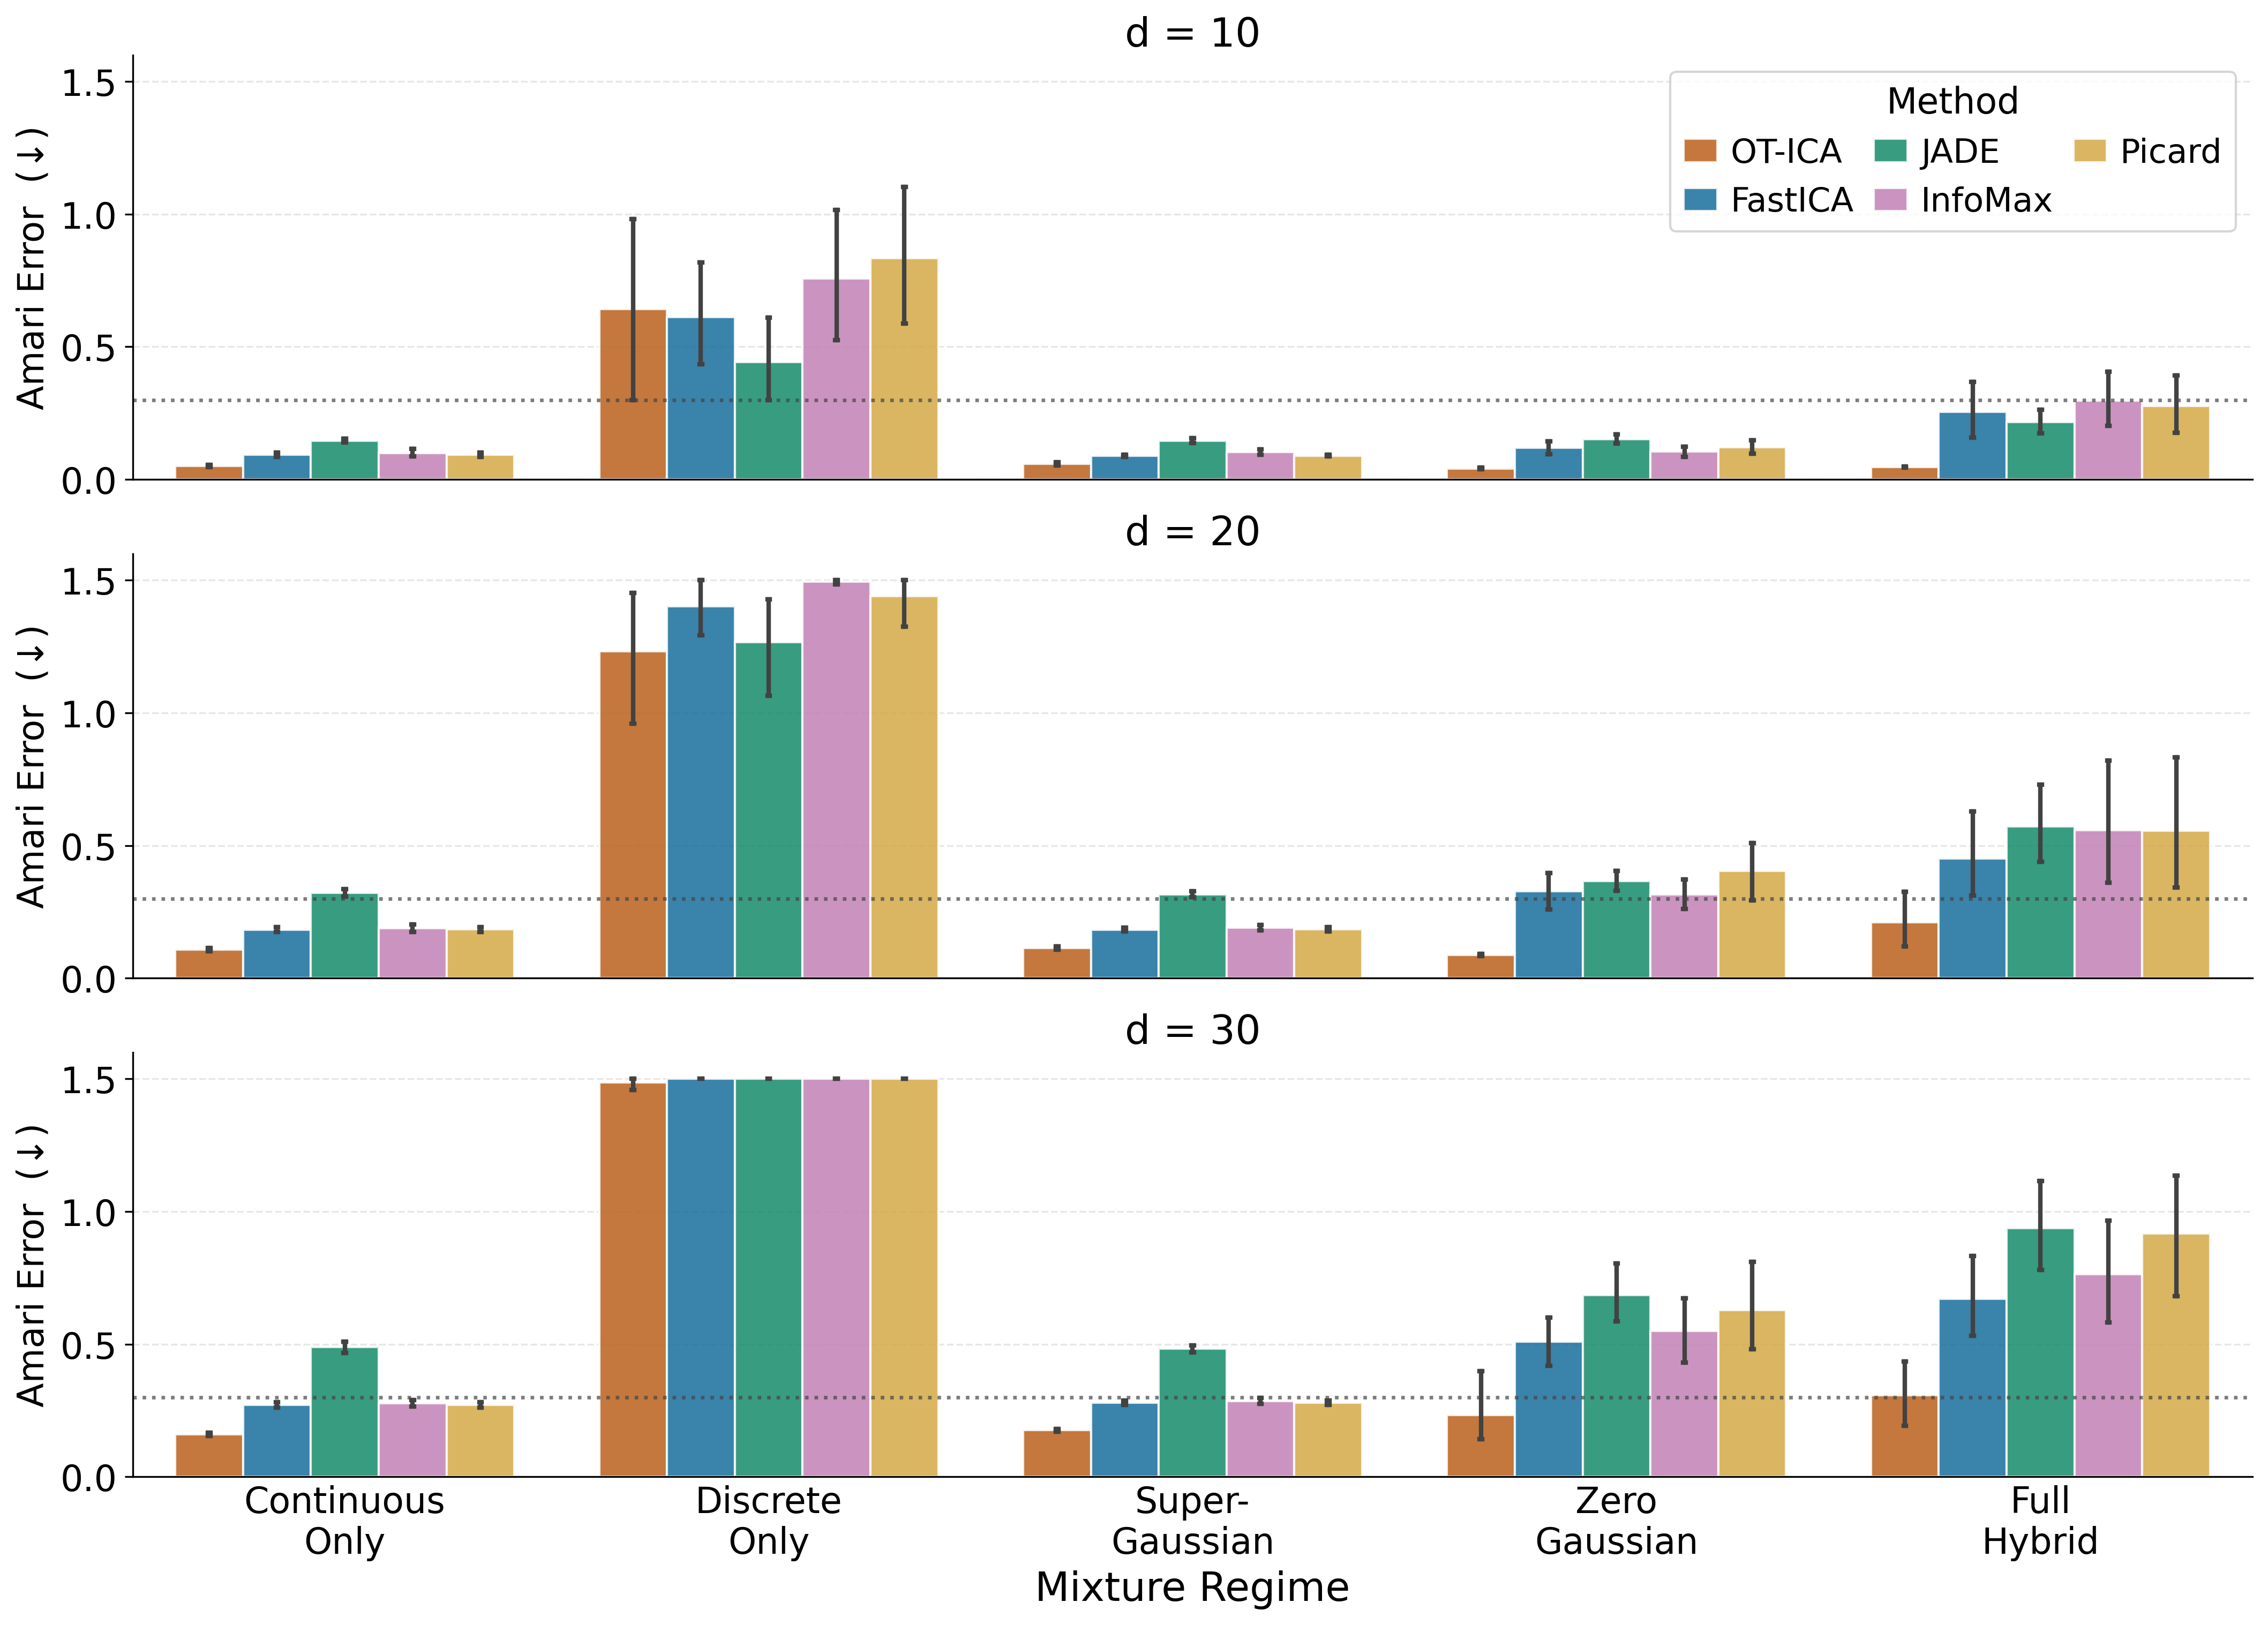

Saved ../uai_workshop/general_hybrid_test.pdf


In [10]:
# =============================================================================
# Figure 2: ablation across dims and mixture types
#           (general_hybrid_test.pdf — 3×1, full two-column width)
# =============================================================================
set_tpm_theme()

CONFIG_LABELS = {
    'Continuous Only':         'Continuous\nOnly',
    'Discrete Only':           'Discrete\nOnly',
    'Strictly Super-Gaussian': 'Super-\nGaussian',
    'Zero Gaussian':           'Zero\nGaussian',
    'Full Hybrid':             'Full\nHybrid',
}
CONFIG_ORDER = [CONFIG_LABELS[p] for p in POOLS]

# 3 rows (one per dim), full two-column width.
# Each panel: ~1.67" print height → total 5" → at 2× SCALE: figsize (14, 10).
fig, axes_abl = plt.subplots(
    3, 1,
    figsize=(FULL_WIDTH_IN * SCALE, 5 * SCALE),
    constrained_layout=True,
)

for ax_idx, (ax, dim) in enumerate(zip(axes_abl, ABL_DIMS)):
    df_dim = df_abl[df_abl['Dim'] == dim].copy()
    df_dim['Config_short'] = df_dim['Config'].map(CONFIG_LABELS)

    sns.barplot(
        data=df_dim, x='Config_short', y='Error', hue='Method',
        hue_order=METHOD_ORDER, order=CONFIG_ORDER,
        palette=PALETTE, ax=ax,
        errorbar='ci', capsize=0.03,
        err_kws={'linewidth': 1.0 * SCALE},
        alpha=0.85, edgecolor='white',
    )
    ax.axhline(0.3, color='#444', ls=':', lw=0.8 * SCALE, alpha=0.7)
    ax.set_ylim(0, 1.6)
    ax.set_ylabel('Amari Error  (↓)', fontsize=8 * SCALE)
    ax.set_title(f'd = {dim}', fontsize=9 * SCALE, pad=4)

    if ax_idx < 2:
        ax.set_xlabel('')
        ax.tick_params(labelbottom=False)
    else:
        ax.set_xlabel('Mixture Regime', fontsize=9 * SCALE)

    if ax_idx == 0:
        ax.legend(title='Method', loc='upper right', ncol=3, frameon=True,
                  handlelength=1.0, handletextpad=0.4, columnspacing=0.6,
                  fontsize=7.5 * SCALE)
    else:
        ax.get_legend().remove()

    ax.tick_params(axis='x', which='both', length=0)

out = SAVE_DIR + 'general_hybrid_test.pdf'
fig.savefig(out, format='pdf', bbox_inches='tight')
plt.show()
print(f'Saved {out}')

Baseline Amari Error: 0.0151


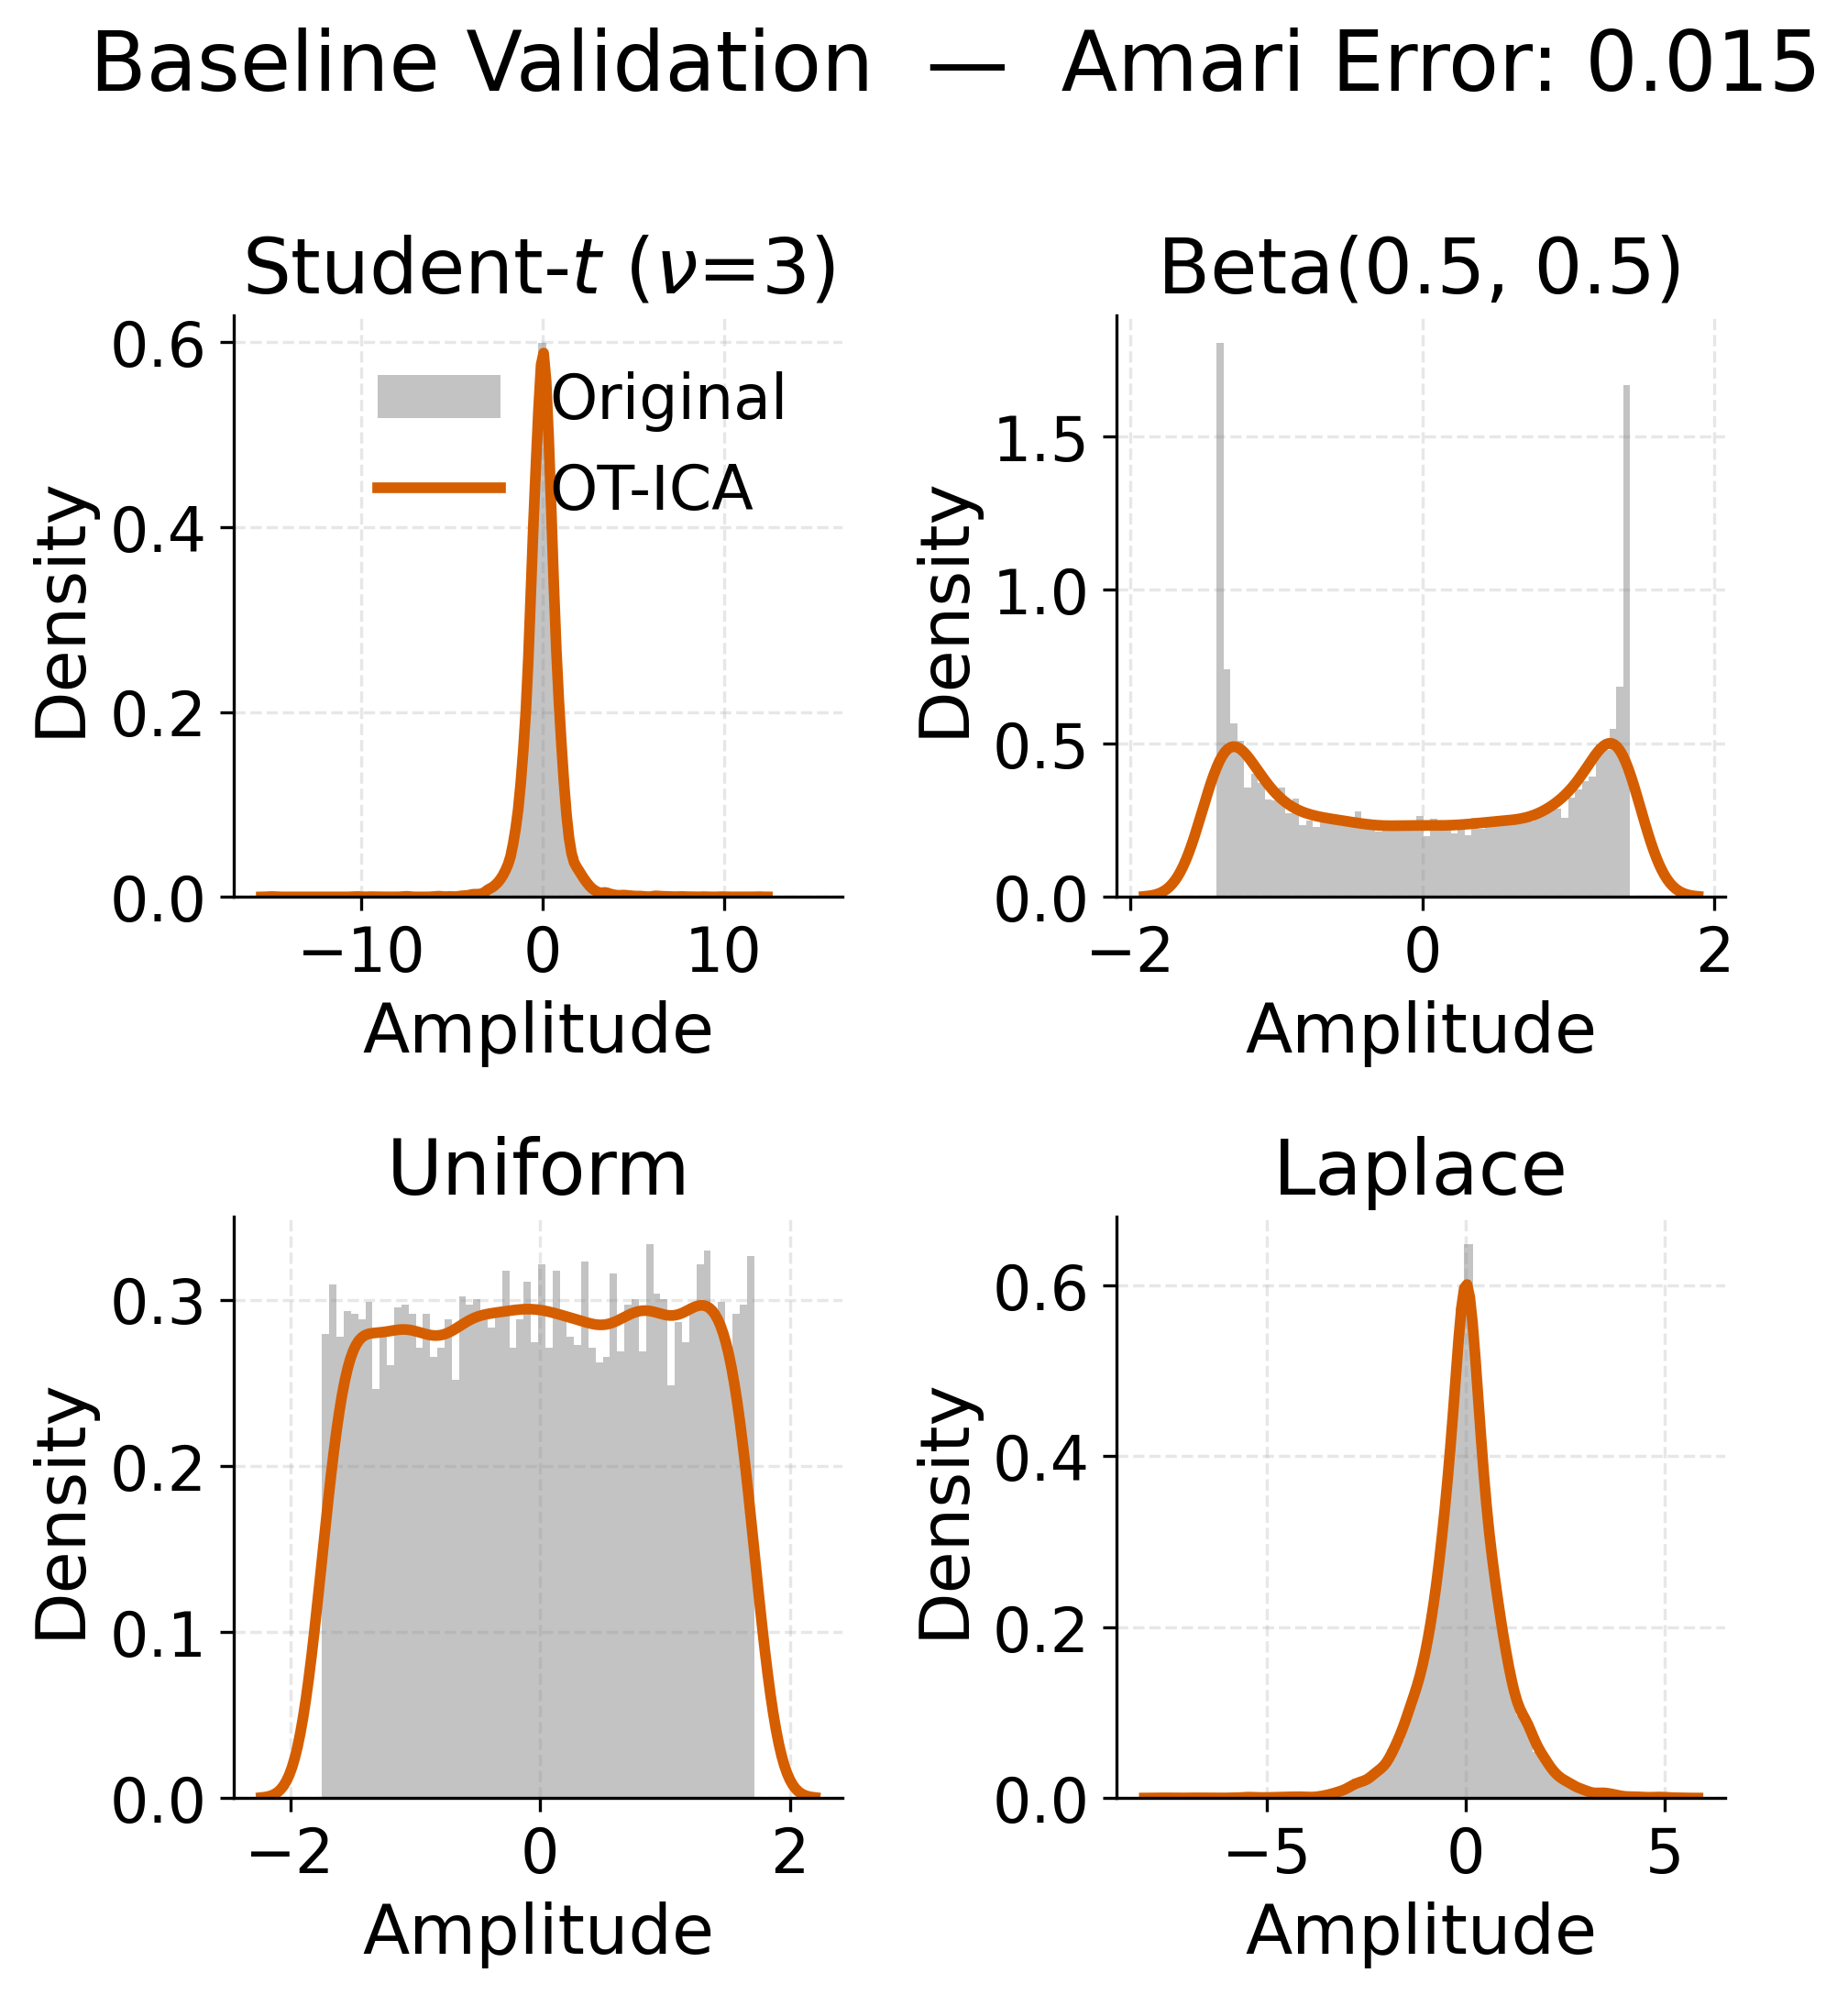

Saved ../uai_workshop/otica_baseline_recovery.pdf


In [11]:
# =============================================================================
# Figure 1: Baseline recovery  (otica_baseline_recovery.pdf)
# =============================================================================
np.random.seed(42); torch.manual_seed(42)
n_base, d_base = 10_000, 4

s1 = np.random.laplace(0, 1/np.sqrt(2), n_base)
s2 = np.random.uniform(-np.sqrt(3), np.sqrt(3), n_base)
s3 = scipy.stats.t.rvs(df=3, size=n_base); s3 = s3 / s3.std()
s4 = np.random.beta(0.5, 0.5, n_base);     s4 = (s4 - s4.mean()) / s4.std()
S_true = np.stack([s1, s2, s3, s4])
S_true = (S_true - S_true.mean(1, keepdims=True)) / S_true.std(1, keepdims=True)
src_names = ['Laplace', 'Uniform', r'Student-$t$ ($\nu$=3)', r'Beta(0.5, 0.5)']

A_base = np.random.randn(d_base, d_base)
while np.linalg.cond(A_base) > 20:
    A_base = np.random.randn(d_base, d_base)
X_base = A_base @ S_true

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
X_t_base = torch.tensor(X_base, dtype=torch.float32, device=device)
ica_base  = WassersteinICA(X_t_base)
ica_base.whiten()
W_wh_base = ica_base.W_white.cpu().numpy()

extracted = []
for _ in range(d_base):
    prev = torch.stack(extracted) if extracted else None
    w, _ = ica_base.optimize_wasserstein2(
        prev_components=prev, max_iter=200, n_restarts=50, dither_sigma=0.01)
    extracted.append(w)

W_sym_base  = ica_base.optimize_symmetric(
    n_components=d_base, max_iter=400, lr=0.25,
    init_w=torch.stack(extracted),
    optimizer='stiefel', dither_sigma=0.01, batch_size=1024)
W_total_base = W_sym_base.cpu().numpy() @ W_wh_base
score_base   = amari_error(W_total_base, A_base)
Y_est_base   = W_total_base @ X_base

print(f'Baseline Amari Error: {score_base:.4f}')

P_match = np.abs(W_total_base @ A_base)
matches = [
    (i, int(np.argmax(P_match[i])), float(np.sign(P_match[i, np.argmax(P_match[i])])))
    for i in range(d_base)
]

set_tpm_theme()
fig, axes = plt.subplots(
    2, 2,
    figsize=(COLUMN_IN * SCALE, COLUMN_IN * SCALE),
    gridspec_kw={'hspace': 0.55, 'wspace': 0.45},
)
axes = axes.flatten()

for ax_idx, (est_idx, src_idx, sgn) in enumerate(matches):
    ax   = axes[ax_idx]
    orig = S_true[src_idx]
    est  = Y_est_base[est_idx] * sgn
    ax.hist(orig, bins=60, density=True, alpha=0.5,
            color='#888888', edgecolor='none', label='Original')
    sns.kdeplot(est, ax=ax, color=PALETTE['OT-ICA'],
                linewidth=1.4 * SCALE, label='OT-ICA')
    ax.set_title(src_names[src_idx])
    ax.set_xlabel('Amplitude')
    ax.set_ylabel('Density')
    if ax_idx == 0:
        ax.legend(loc='upper right', frameon=False)

fig.suptitle(f'Baseline Validation  —  Amari Error: {score_base:.3f}', y=1.03)
out = SAVE_DIR + 'otica_baseline_recovery.pdf'
fig.savefig(out, format='pdf', bbox_inches='tight')
plt.show()
print(f'Saved {out}')

Loading MNE sample dataset …
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
EEG shape: (5, 6007)  (6007 samples @ 601 Hz)
Artifact component (Comp 1) kurtosis: 59.52
Mean kurtosis of remaining components:              -0.05
RMS reduction in ±250 ms blink window: 92.4%


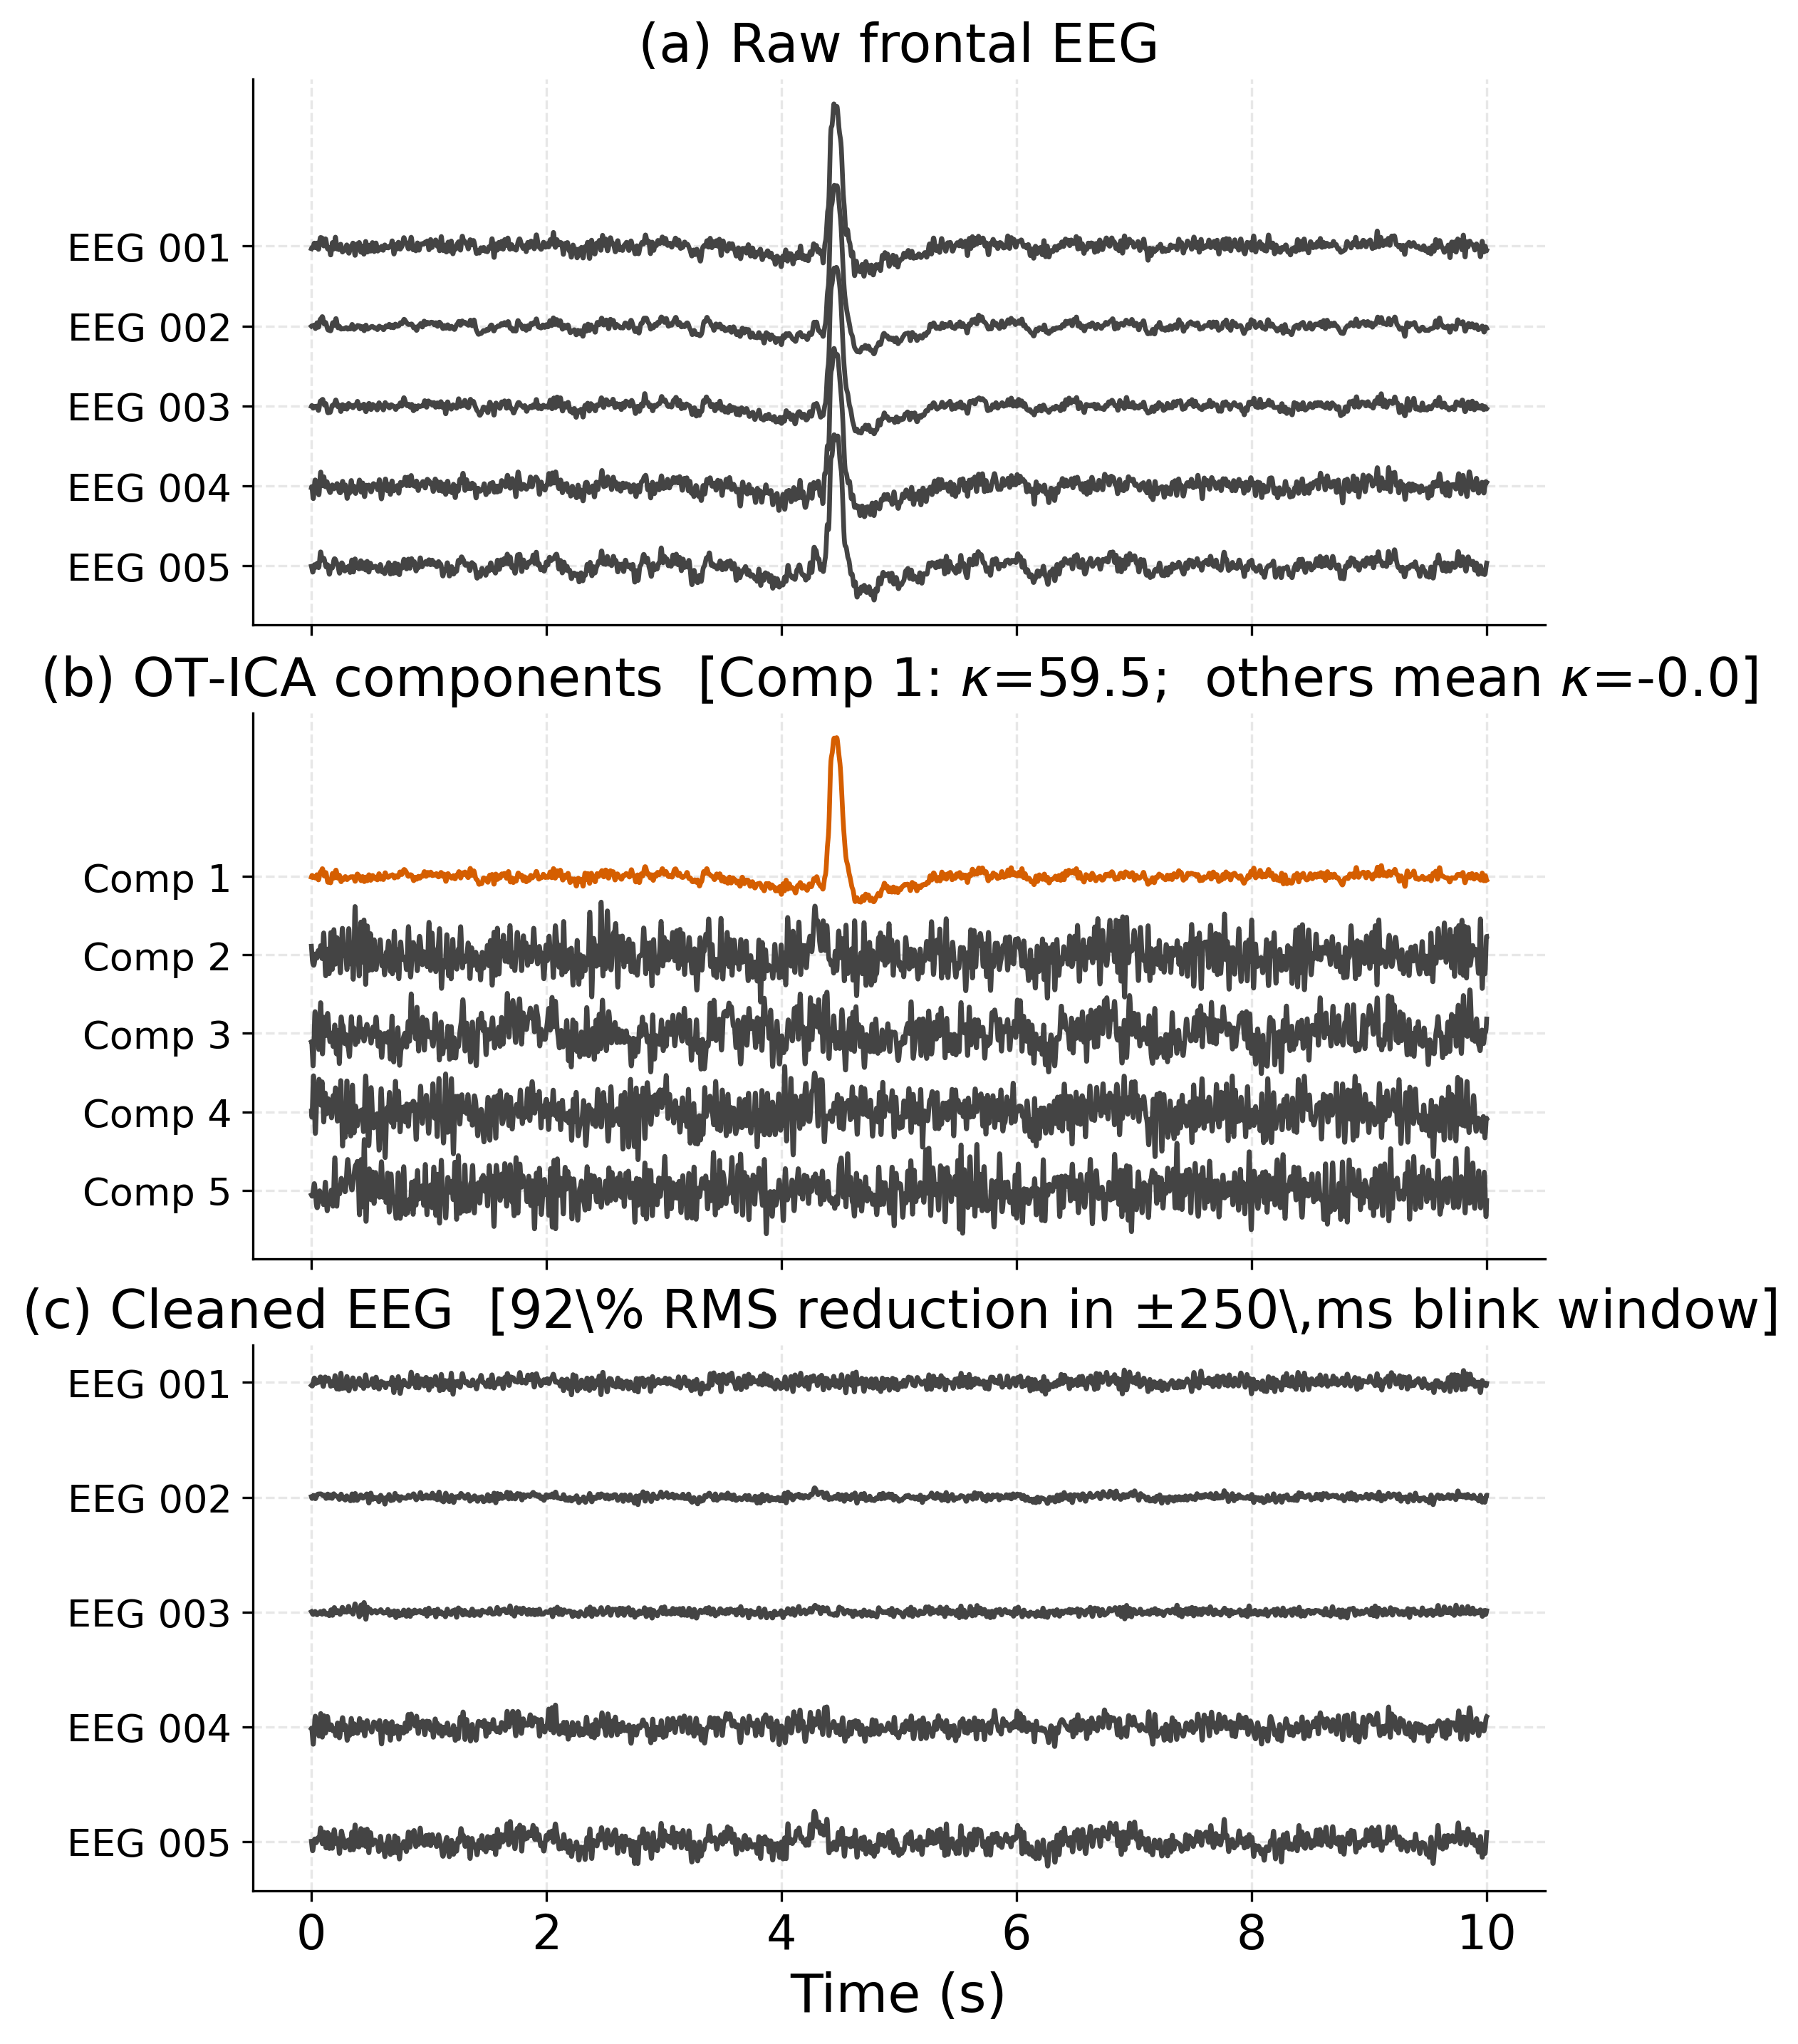

Saved ../uai_workshop/eeg_artifact_removal.pdf

All TPM 2026 figures written to ../uai_workshop/


In [12]:
# ---- Load MNE sample data (downloads ~1.5 GB on first run) -----------------
print('Loading MNE sample dataset …')
sample_data_folder   = mne.datasets.sample.data_path()
sample_data_raw_file = (sample_data_folder / 'MEG' / 'sample'
                        / 'sample_audvis_raw.fif')

raw = mne.io.read_raw_fif(sample_data_raw_file, preload=True, verbose=False)
raw.filter(l_freq=1.0, h_freq=40.0, fir_design='firwin', verbose=False)
raw.crop(tmin=10.0, tmax=20.0)

frontal_channels = ['EEG 001', 'EEG 002', 'EEG 003', 'EEG 004', 'EEG 005']
raw.pick_channels(frontal_channels)

X_eeg = raw.get_data()
time  = raw.times
sfreq = raw.info['sfreq']
dim_eeg = X_eeg.shape[0]

X_eeg = (X_eeg - X_eeg.mean(1, keepdims=True)) / X_eeg.std(1, keepdims=True)
print(f'EEG shape: {X_eeg.shape}  ({X_eeg.shape[1]} samples @ {sfreq:.0f} Hz)')

# ---- Run OT-ICA ------------------------------------------------------------
X_t_eeg  = torch.tensor(X_eeg, dtype=torch.float32, device=device)
model_eeg = WassersteinICA(X_t_eeg)
model_eeg.whiten()

extracted_eeg = []
for _ in range(dim_eeg):
    prev = torch.stack(extracted_eeg) if extracted_eeg else None
    w, _ = model_eeg.optimize_wasserstein2(
        prev_components=prev, max_iter=200, n_restarts=50, dither_sigma=0.01)
    extracted_eeg.append(w)

W_eeg = model_eeg.optimize_symmetric(
    n_components=dim_eeg, max_iter=400, lr=0.05,
    init_w=torch.stack(extracted_eeg),
    optimizer='stiefel', batch_size=512, dither_sigma=0.01)

W_eeg_np   = W_eeg.cpu().numpy()
W_white_np = model_eeg.W_white.cpu().numpy()
Z_hat      = W_eeg_np @ model_eeg.X_white.cpu().numpy()

# ---- Identify artifact component via excess kurtosis -----------------------
kurtoses     = scipy.stats.kurtosis(Z_hat, axis=1)
artifact_idx = int(np.argmax(kurtoses))

kurtosis_artifact = float(kurtoses[artifact_idx])
kurtosis_others   = float(np.mean([kurtoses[i] for i in range(dim_eeg)
                                    if i != artifact_idx]))
print(f'Artifact component (Comp {artifact_idx+1}) kurtosis: {kurtosis_artifact:.2f}')
print(f'Mean kurtosis of remaining components:              {kurtosis_others:.2f}')

# Align blink spike to positive orientation (sign ambiguity of ICA)
peak_sample = int(np.argmax(np.abs(Z_hat[artifact_idx])))
if Z_hat[artifact_idx, peak_sample] < 0:
    Z_hat[artifact_idx] = -Z_hat[artifact_idx]

# ---- Reconstruct cleaned signal (zero the artifact component) --------------
W_total_eeg = W_eeg_np @ W_white_np          # full (d, d) unmixing
W_total_inv = np.linalg.inv(W_total_eeg)     # exact inverse (W_eeg orthogonal, W_white invertible)

Z_cleaned = Z_hat.copy()
Z_cleaned[artifact_idx] = 0.0
X_cleaned = W_total_inv @ Z_cleaned          # back to normalised EEG space

# ---- Quantitative: RMS reduction in ±250 ms blink window ------------------
hw  = int(0.25 * sfreq)
win = slice(max(0, peak_sample - hw), min(X_eeg.shape[1], peak_sample + hw))
rms_before    = float(np.sqrt(np.mean(X_eeg[:, win]**2)))
rms_after     = float(np.sqrt(np.mean(X_cleaned[:, win]**2)))
pct_reduction = (1.0 - rms_after / rms_before) * 100.0
print(f'RMS reduction in ±250 ms blink window: {pct_reduction:.1f}%')

# ---- Plot (3 rows: raw / components / cleaned) -----------------------------
set_tpm_theme()

OFFSET = 5.5
comp_colors = ['#D55E00' if i == artifact_idx else '#444444' for i in range(dim_eeg)]
comp_labels = [f'Comp {i+1}' for i in range(dim_eeg)]

fig, axes_eeg = plt.subplots(
    3, 1,
    figsize=(COLUMN_IN * SCALE, COLUMN_IN * SCALE * 1.35),
    sharex=True,
    constrained_layout=True,
)

# Panel (a): raw EEG
for i in range(dim_eeg):
    axes_eeg[0].plot(time, X_eeg[i] - i * OFFSET,
                     color='#444444', linewidth=0.8 * SCALE)
axes_eeg[0].set_yticks([-OFFSET * i for i in range(dim_eeg)])
axes_eeg[0].set_yticklabels(frontal_channels)
axes_eeg[0].set_title('(a) Raw frontal EEG', fontsize=9 * SCALE)

# Panel (b): OT-ICA components, with kurtosis contrast in title
for i in range(dim_eeg):
    axes_eeg[1].plot(time, Z_hat[i] - i * OFFSET,
                     color=comp_colors[i], linewidth=0.8 * SCALE)
axes_eeg[1].set_yticks([-OFFSET * i for i in range(dim_eeg)])
axes_eeg[1].set_yticklabels(comp_labels)
axes_eeg[1].set_title(
    f'(b) OT-ICA components  '
    f'[Comp {artifact_idx+1}: $\\kappa$={kurtosis_artifact:.1f};  '
    f'others mean $\\kappa$={kurtosis_others:.1f}]',
    fontsize=9 * SCALE,
)

# Panel (c): cleaned EEG, with RMS reduction in title
for i in range(dim_eeg):
    axes_eeg[2].plot(time, X_cleaned[i] - i * OFFSET,
                     color='#444444', linewidth=0.8 * SCALE)
axes_eeg[2].set_yticks([-OFFSET * i for i in range(dim_eeg)])
axes_eeg[2].set_yticklabels(frontal_channels)
axes_eeg[2].set_title(
    f'(c) Cleaned EEG  [{pct_reduction:.0f}\\% RMS reduction in $\\pm$250\\,ms blink window]',
    fontsize=9 * SCALE,
)
axes_eeg[2].set_xlabel('Time (s)')

for ax in axes_eeg:
    ax.tick_params(axis='y', labelsize=6.5 * SCALE)

out = SAVE_DIR + 'eeg_artifact_removal.pdf'
fig.savefig(out, format='pdf', bbox_inches='tight')
plt.show()
print(f'Saved {out}')

print('\nAll TPM 2026 figures written to', SAVE_DIR)